# Testes de hipóteses paramétricos

Os métodos paramétricos são aplicados para dados quantitativos e exigem suposições fortes para sua validação, incluindo:

- as observações devem ser independentes;
- a amostra deve ser retirada de populações com determinada distribuição, geralmente a normal;
- as populações devem ter variâncias iguais para testes de comparação de duas médias populacionais emparelhadas ou $k$ médias populacionais ($k \ge 3$);
- as variáveis em estudo devem ser medidas em escala intervalar ou de razão, do modo que seja possível utilizar operações aritméticas sobre os respectivos valores.

## Teste t de Student para comparação de duas médias populacionais a partir de duas amostras aleatórias independentes

O teste t para duas amostras independentes é aplicado para comparar as médias de duas amostras aleatórias ($X_{1i}, i = 1, \ldots , n_1$; $X_{2j}, j = 1, ... , n_2$) extraídas da mesma população. Neste teste, a variância populacional é desconhecida.

Para um teste bilateral, as hipóteses são:

- $H_0$: $\mu_1 = \mu_2$
- $H_1$: $\mu_1 \neq \mu_2$

O cálculo da estatística *T* depende da comparação das variâncias populacionais entre os grupos. Daí a necessidade de testar a homogeneidade antes. E, também, assume normalidade das duas populações.

Exemplo: Um engenheiro de qualidade desconfia que o tempo médio de fabricação de determinado produto plástico pode depender da matéria-prima utilizada que é proveniente de dois fornecedores. A base a seguir apresenta 30 observações de cada fornecedor. Para o nível de significância de 5%, verifique se há diferença entre as médias.

In [1]:
import pandas as pd

BASE_FORNECEDORES = "./dados/suppliers.csv"

df_fornecedores = pd.read_csv(BASE_FORNECEDORES)

df_fornecedores.head()

,supplier_1,supplier_2
0,22.8,26.8
1,23.4,29.3
2,26.2,28.4
3,24.3,25.6
4,22.0,29.4


In [2]:
df_fornecedores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   supplier_1  30 non-null     float64
 1   supplier_2  30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [3]:
df_fornecedores.describe()

,supplier_1,supplier_2
count,30.000000,30.000000
mean,24.276667,27.530000
std,1.345409,1.248489
min,22.000000,25.400000
25%,23.125000,26.800000
50%,24.250000,27.450000
75%,25.100000,28.475000
max,26.700000,29.700000


<Axes: ylabel='Count'>

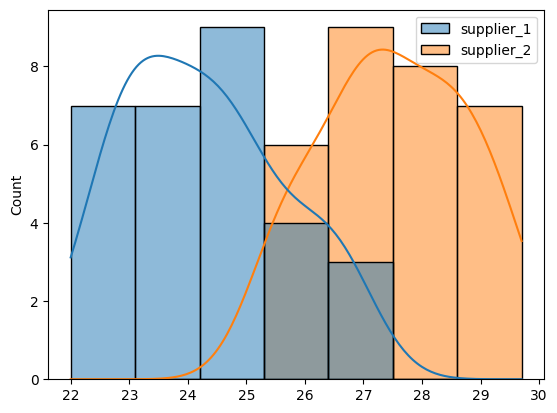

In [4]:
import seaborn as sns

sns.histplot(df_fornecedores,kde=True)

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html

<Axes: >

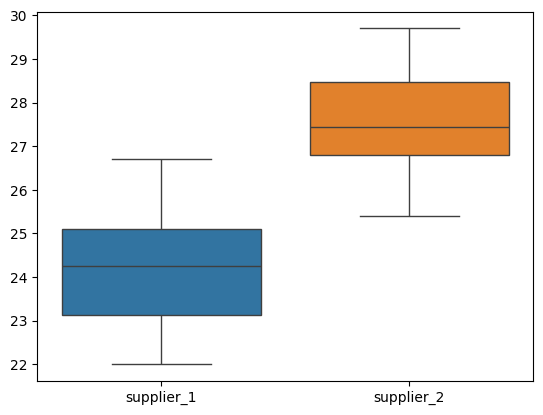

In [5]:
sns.boxplot(df_fornecedores)

In [6]:
from auxiliares import analises_shapiro_levene

analises_shapiro_levene(df_fornecedores)

teste de shapiro
 estatistica_sw =0.945
supplier_1 segue uma distribuição normal (valor p: 0.127)
 estatistica_sw =0.959
supplier_2 segue uma distribuição normal (valor p: 0.298)

teste de levene
estatistica_levene =0.156
Variancia Iguais (valor p: 0.694)


In [7]:
from scipy.stats import ttest_ind

ttest_ind(df_fornecedores['supplier_1'], df_fornecedores['supplier_2'],equal_var=True)

TtestResult(statistic=np.float64(-9.70841463275532), pvalue=np.float64(9.18577752538684e-14), df=np.float64(58.0))

In [8]:
from auxiliares import analise_ttest_ind

analise_ttest_ind(df_fornecedores)

teste de TT mais de uma variavel
estatistica_levene =-9.708
Rejeita a hipótese nula (valor p: 0.000)
